In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

print ("Pandas version: ", pd.__version__)
print ("Numpy version: ", np.__version__)

Pandas version:  3.0.3
Numpy version:  2.4.6


In [2]:
station_id = "USW00012960"
url = f"https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/{station_id}.csv"
print("Download from:", url)

df = pd.read_csv(url)

print("Dowload Complete")
print("Dataframe shape:", df.shape)

Download from: https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/USW00012960.csv


C:\Users\SUDARSHAN\AppData\Local\Temp\ipykernel_24248\966782463.py:5: DtypeWarning: Columns (0: ACMH_ATTRIBUTES, 1: ACSH_ATTRIBUTES, 2: ADPT_ATTRIBUTES, 3: ASLP_ATTRIBUTES, 4: ASTP_ATTRIBUTES, 5: AWBT_ATTRIBUTES, 6: FMTM_ATTRIBUTES, 7: PSUN_ATTRIBUTES, 8: RHAV_ATTRIBUTES, 9: RHMN_ATTRIBUTES, 10: RHMX_ATTRIBUTES, 11: TAVG_ATTRIBUTES, 12: TSUN_ATTRIBUTES, 13: WDF1_ATTRIBUTES, 14: WDF2_ATTRIBUTES, 15: WDF5_ATTRIBUTES, 16: WDFG_ATTRIBUTES, 17: WESD_ATTRIBUTES, 18: WSF1_ATTRIBUTES, 19: WSF2_ATTRIBUTES, 20: WSF5_ATTRIBUTES, 21: WSFG_ATTRIBUTES, 22: WT09_ATTRIBUTES, 23: WT10_ATTRIBUTES, 24: WT11_ATTRIBUTES, 25: WT13_ATTRIBUTES, 26: WT14_ATTRIBUTES, 27: WT15_ATTRIBUTES, 28: WT16_ATTRIBUTES, 29: WT17_ATTRIBUTES, 30: WT18_ATTRIBUTES, 31: WT21_ATTRIBUTES, 32: WV03_ATTRIBUTES) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


Dowload Complete
Dataframe shape: (20848, 102)


In [3]:
# Reload cleanly — low_memory=False tells pandas to read the whole
# column before deciding its type, which removes the mixed-type warning
df = pd.read_csv(url, low_memory=False)

# Show how many columns and list the first 20 names
print("Total columns:", len(df.columns))
print()
print("First 20 column names:")
print(list(df.columns[:20]))

Total columns: 102

First 20 column names:
['STATION', 'DATE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME', 'PRCP', 'PRCP_ATTRIBUTES', 'SNOW', 'SNOW_ATTRIBUTES', 'SNWD', 'SNWD_ATTRIBUTES', 'TMAX', 'TMAX_ATTRIBUTES', 'TMIN', 'TMIN_ATTRIBUTES', 'ACMH', 'ACMH_ATTRIBUTES', 'ACSH', 'ACSH_ATTRIBUTES']


In [ ]:
keep_columns = ["STATION", "DATE", "LATITUDE", "LONGITUDE", "ELEVATION", "NAME", "PRCP", "SNOW", "SNWD", "TMAX", "TMIN"]

df_clean = df[keep_columns].copy() #.copy() create a new dataframe, not a view of the original

print("New Shape:", df_clean.shape)
print("First 5 rows:", df_clean.head())

New Shape: (20848, 11)
First 5 rows:        STATION        DATE  LATITUDE  LONGITUDE  ELEVATION  \
0  USW00012960  1969-06-01  29.98438  -95.36072       27.5   
1  USW00012960  1969-06-02  29.98438  -95.36072       27.5   
2  USW00012960  1969-06-03  29.98438  -95.36072       27.5   
3  USW00012960  1969-06-04  29.98438  -95.36072       27.5   
4  USW00012960  1969-06-05  29.98438  -95.36072       27.5   

                                      NAME  PRCP  SNOW  SNWD  TMAX  TMIN  
0  HOUSTON INTERCONTINENTAL AIRPORT, TX US     0   0.0   0.0   322   222  
1  HOUSTON INTERCONTINENTAL AIRPORT, TX US    46   0.0   0.0   294   167  
2  HOUSTON INTERCONTINENTAL AIRPORT, TX US    15   0.0   0.0   267   156  
3  HOUSTON INTERCONTINENTAL AIRPORT, TX US   323   0.0   0.0   189   156  
4  HOUSTON INTERCONTINENTAL AIRPORT, TX US     0   0.0   0.0   256   133  


In [5]:
# This is to find out the useless columns in the dataframe.
# For each column, what % of values are missing?
missing_pct = (df.isna().mean() * 100).round(1)

# Sort from least missing to most, show all
missing_pct_sorted = missing_pct.sort_values()

# Show the 25 most-complete columns
print("Most complete columns (% missing):")
print(missing_pct_sorted.head(25))

Most complete columns (% missing):
STATION             0.0
DATE                0.0
LATITUDE            0.0
LONGITUDE           0.0
ELEVATION           0.0
NAME                0.0
PRCP                0.0
PRCP_ATTRIBUTES     0.0
SNOW                0.0
SNOW_ATTRIBUTES     0.0
SNWD                0.0
SNWD_ATTRIBUTES     0.0
TMAX                0.0
TMAX_ATTRIBUTES     0.0
TMIN                0.0
TMIN_ATTRIBUTES     0.0
AWND               25.6
AWND_ATTRIBUTES    25.6
PGTM_ATTRIBUTES    29.6
PGTM               29.6
TSUN_ATTRIBUTES    45.6
TSUN               45.6
WSF2               47.3
WSF2_ATTRIBUTES    47.3
WDF2               47.3
dtype: float64


In [6]:
# Converting Units to Real Numbers
# Convert tenths to real units by dividing by 10
df_clean["TMAX"] = df_clean["TMAX"] / 10   # tenths °C  -> °C
df_clean["TMIN"] = df_clean["TMIN"] / 10   # tenths °C  -> °C
df_clean["PRCP"] = df_clean["PRCP"] / 10   # tenths mm  -> mm

# SNOW and SNWD are already in mm, so we leave them unchanged

# Look at the result
df_clean.head()

,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,PRCP,SNOW,SNWD,TMAX,TMIN
0,USW00012960,1969-06-01,29.98438,-95.36072,27.5,"HOUSTON INTERCONTINENTAL AIRPORT, TX US",0.0,0.0,0.0,32.2,22.2
1,USW00012960,1969-06-02,29.98438,-95.36072,27.5,"HOUSTON INTERCONTINENTAL AIRPORT, TX US",4.6,0.0,0.0,29.4,16.7
2,USW00012960,1969-06-03,29.98438,-95.36072,27.5,"HOUSTON INTERCONTINENTAL AIRPORT, TX US",1.5,0.0,0.0,26.7,15.6
3,USW00012960,1969-06-04,29.98438,-95.36072,27.5,"HOUSTON INTERCONTINENTAL AIRPORT, TX US",32.3,0.0,0.0,18.9,15.6
4,USW00012960,1969-06-05,29.98438,-95.36072,27.5,"HOUSTON INTERCONTINENTAL AIRPORT, TX US",0.0,0.0,0.0,25.6,13.3


In [7]:
# Converting the DATE column to datetime type
# Convert the DATE column from text into real datetime objects
df_clean["DATE"] = pd.to_datetime(df_clean["DATE"])

# Check that it worked by looking at the column types
print(df_clean.dtypes)

STATION                 str
DATE         datetime64[us]
LATITUDE            float64
LONGITUDE           float64
ELEVATION           float64
NAME                    str
PRCP                float64
SNOW                float64
SNWD                float64
TMAX                float64
TMIN                float64
dtype: object


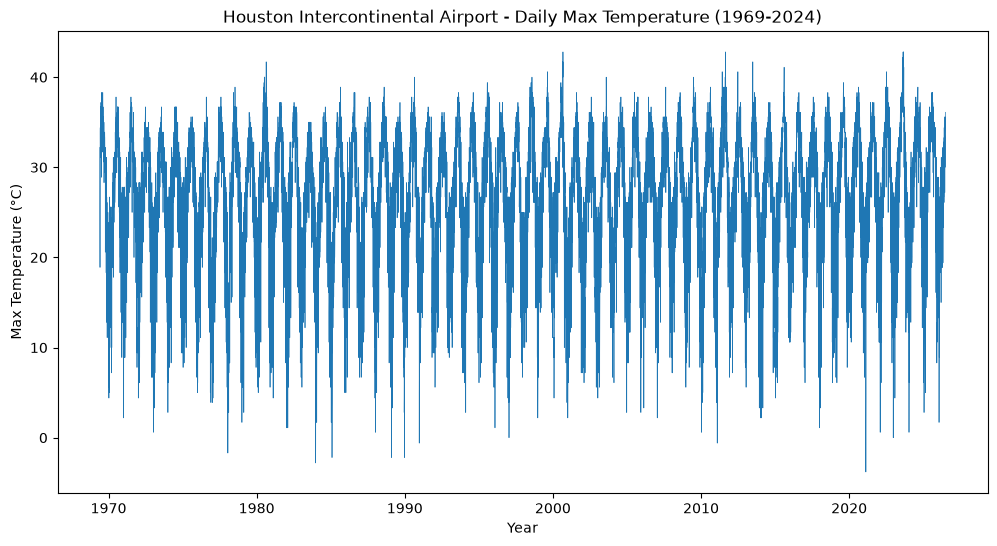

In [9]:
#Visulaization of the data
plt.figure(figsize=(12, 6))
plt.plot(df_clean["DATE"],df_clean["TMAX"], linewidth=0.5)
plt.title("Houston Intercontinental Airport - Daily Max Temperature (1969-2024)")
plt.xlabel("Year")
plt.ylabel("Max Temperature (°C)")

plt.show()
           